In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import folium


In [37]:
df = pd.read_csv("Bangladesh-Crime-Dataset.csv")

In [38]:
df.head()

,Unnamed: 0,incident_month,incident_week,incident_weekday,weekend,part_of_the_day,latitude,longitude,incident_place,incident_district,...,literacy_rate,religious_institution,playground,park,police_station,cyber_cafe,school,college,cinema,crime
0,0,7,29,wednesday,0,morning,23.774569,90.355292,adabar,dhaka,...,74.6,4289,99,17,60,478,242,64,40,murder
1,1,1,2,wednesday,0,night,23.774569,90.355292,adabar,dhaka,...,74.6,4289,99,17,60,478,242,64,40,murder
2,2,1,4,tuesday,0,night,23.769808,90.351595,adabor,dhaka,...,74.6,4289,99,17,60,478,242,64,40,murder
3,3,3,9,friday,1,night,23.728907,90.417137,aftabnagar,dhaka,...,74.6,4289,99,17,60,478,242,64,40,murder
4,4,8,34,thursday,0,night,23.847177,90.404133,airport,dhaka,...,74.6,4289,99,17,60,478,242,64,40,murder


In [39]:
df.shape

(6574, 38)

In [40]:
df["weekend"].unique()

array([0, 1])

In [41]:
df.drop("Unnamed: 0", axis=1, inplace=True)

In [42]:
df.head(25)

,incident_month,incident_week,incident_weekday,weekend,part_of_the_day,latitude,longitude,incident_place,incident_district,incident_division,...,literacy_rate,religious_institution,playground,park,police_station,cyber_cafe,school,college,cinema,crime
0,7,29,wednesday,0,morning,23.774569,90.355292,adabar,dhaka,dhaka,...,74.6,4289,99,17,60,478,242,64,40,murder
1,1,2,wednesday,0,night,23.774569,90.355292,adabar,dhaka,dhaka,...,74.6,4289,99,17,60,478,242,64,40,murder
2,1,4,tuesday,0,night,23.769808,90.351595,adabor,dhaka,dhaka,...,74.6,4289,99,17,60,478,242,64,40,murder
3,3,9,friday,1,night,23.728907,90.417137,aftabnagar,dhaka,dhaka,...,74.6,4289,99,17,60,478,242,64,40,murder
4,8,34,thursday,0,night,23.847177,90.404133,airport,dhaka,dhaka,...,74.6,4289,99,17,60,478,242,64,40,murder
5,8,34,thursday,0,night,23.847177,90.404133,airport,dhaka,dhaka,...,74.6,4289,99,17,60,478,242,64,40,murder
6,2,7,sunday,0,night,23.913894,90.320686,ashulia,dhaka,dhaka,...,68.0,1118,78,3,6,16,42,10,3,murder
7,1,1,saturday,1,evening,23.913894,90.320686,ashulia,dhaka,dhaka,...,68.0,1118,78,3,6,16,42,10,3,murder
8,1,2,friday,1,evening,23.913894,90.320686,ashulia,dhaka,dhaka,...,68.0,1118,78,3,6,16,42,10,3,murder
9,2,7,sunday,0,night,23.913894,90.320686,ashulia,dhaka,dhaka,...,68.0,1118,78,3,6,16,42,10,3,murder


In [43]:
df.gender_ration.unique()

array([125, 114, 101,  90, 113,  88, 116,  97,  96, 102,  98,  99, 110,
        94,  89,  86, 109, 107, 108, 100,  93, 103, 105, 104,  95, 117,
        91,  92, 106, 111, 203,  85,  84,  87])

In [44]:
df_copy = df.copy()

In [45]:
df.isna().sum().sum()

np.int64(0)

In [46]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6574 entries, 0 to 6573
Data columns (total 37 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   incident_month          6574 non-null   int64  
 1   incident_week           6574 non-null   int64  
 2   incident_weekday        6574 non-null   str    
 3   weekend                 6574 non-null   int64  
 4   part_of_the_day         6574 non-null   str    
 5   latitude                6574 non-null   float64
 6   longitude               6574 non-null   float64
 7   incident_place          6574 non-null   str    
 8   incident_district       6574 non-null   str    
 9   incident_division       6574 non-null   str    
 10  max_temp                6574 non-null   int64  
 11  avg_temp                6574 non-null   int64  
 12  min_temp                6574 non-null   int64  
 13  weather_code            6574 non-null   int64  
 14  precip                  6574 non-null   float64
 15

## The dataset contains crime events collected over seven years. However, since exact dates and years are unavailable, the temporal features are analyzed as recurring seasonal and weekly patterns rather than as a chronological seven-year timeline.

In [47]:
crime_details = df.groupby(["incident_place", "incident_month", "incident_week", "incident_weekday"])["crime"].count()
print(crime_details)

incident_place  incident_month  incident_week  incident_weekday
abhaynagar      1               2              sunday              1
                                4              saturday            1
                2               7              friday              1
                                8              sunday              1
                                               thursday            1
                                                                  ..
zianagar        6               22             saturday            1
                7               30             thursday            1
                8               35             friday              1
                9               37             saturday            1
                10              40             wednesday           1
Name: crime, Length: 5858, dtype: int64


In [48]:
df.describe()

,incident_month,incident_week,weekend,latitude,longitude,max_temp,avg_temp,min_temp,weather_code,precip,...,density_per_kmsq,literacy_rate,religious_institution,playground,park,police_station,cyber_cafe,school,college,cinema
count,6574.000000,6574.000000,6574.000000,6574.000000,6574.000000,6574.000000,6574.000000,6574.000000,6574.000000,6574.000000,...,6574.000000,6574.000000,6574.00000,6574.000000,6574.000000,6574.000000,6574.000000,6574.000000,6574.000000,6574.000000
mean,6.193185,25.193946,0.273806,23.889900,90.213444,32.673258,29.214481,24.114694,222.257225,6.187998,...,6362.512017,55.748829,1232.03164,42.504411,3.863706,11.771372,72.312443,75.218893,15.479617,7.396714
std,3.321934,14.517965,0.445944,1.051299,1.004609,3.452756,3.511377,3.982991,116.678263,11.989998,...,10368.342248,12.045279,1245.17044,44.857967,5.883186,19.612903,160.570311,71.743767,19.721917,12.935065
min,1.000000,1.000000,0.000000,20.866700,88.141700,17.000000,16.000000,8.000000,113.000000,0.000000,...,23.000000,26.700000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,3.000000,13.000000,0.000000,23.180315,89.375000,31.000000,27.000000,21.000000,113.000000,0.000000,...,924.000000,46.800000,519.00000,5.000000,0.000000,2.000000,0.000000,30.000000,4.000000,1.000000
50%,6.000000,25.000000,0.000000,23.858330,90.268302,33.000000,30.000000,25.000000,176.000000,0.800000,...,1239.000000,53.900000,818.00000,25.000000,1.000000,3.000000,1.000000,45.000000,8.000000,2.000000
75%,9.000000,37.000000,1.000000,24.585009,90.652500,35.000000,32.000000,27.000000,356.000000,7.500000,...,3977.000000,67.200000,1125.00000,78.000000,3.000000,6.000000,16.000000,86.000000,15.000000,5.000000
max,12.000000,53.000000,1.000000,26.482740,92.437760,45.000000,40.000000,32.000000,389.000000,204.600000,...,30551.000000,74.600000,4289.00000,253.000000,17.000000,74.000000,478.000000,242.000000,64.000000,40.000000


## Descriptive Analysis

- Found outlier in gender_ration, gender_ration basically indicates how many men there are for every 100 women in an area. It seems 2:1 ratio present in dataset in 4th quartile. Its quite suspicious. From other fields like playground, park, police_station, cyber_cafe, school and college also may have outliers. Lets check boxplot.

In [49]:
df.isna().sum().sum()

np.int64(0)

## Temporal Analysis

In [50]:
week_wise_crime_avg = df.groupby("incident_weekday")["crime"].value_counts(ascending=False)
print(week_wise_crime_avg)

incident_weekday  crime    
friday            murder       216
                  bodyfound    208
                  rape         171
                  assault      134
                  kidnap        86
                  robbery       68
monday            murder       236
                  bodyfound    226
                  assault      165
                  rape         164
                  robbery      110
                  kidnap        83
saturday          bodyfound    228
                  murder       204
                  rape         152
                  assault      150
                  kidnap       109
                  robbery       74
sunday            murder       194
                  bodyfound    179
                  rape         166
                  assault      152
                  kidnap        92
                  robbery       84
thursday          bodyfound    234
                  murder       192
                  rape         179
                  assault  

In [67]:
total_crime_per_weekday = df["incident_weekday"].value_counts()
print(f"Maximum crime on each weekday:\n {total_crime_per_weekday}")

Maximum crime on each weekday:
 incident_weekday
tuesday      1010
monday        984
wednesday     976
thursday      937
saturday      917
friday        883
sunday        867
Name: count, dtype: int64


In [72]:
murder_df = df[df["crime"] == "murder"]
murder_per_weekday = murder_df["incident_weekday"].value_counts(ascending=False)
print(f"Murder summery:\n{murder_per_weekday}")

Murder summery:
incident_weekday
tuesday      241
monday       236
wednesday    235
friday       216
saturday     204
sunday       194
thursday     192
Name: count, dtype: int64


In [53]:
df['incident_week'].unique()

array([29,  2,  4,  9, 34,  7,  1, 46, 45, 36, 23, 14, 31, 19, 37,  3, 16,
       12, 44, 26, 40, 21, 24, 10,  5, 11, 35, 25,  8, 28, 32, 30,  6, 17,
       20, 22, 18, 49, 51, 33, 43, 52, 15, 27, 38, 13, 42, 48, 47, 41, 39,
       50, 53])

In [73]:
unique_weeks_per_weekday = df.groupby("incident_weekday")["incident_week"].nunique()
avg_murder_per_weekday = murder_per_weekday/unique_weeks_per_weekday
print(f"Average murder on every weekday:\n {avg_murder_per_weekday}")


Average murder on every weekday:
 incident_weekday
friday       4.075472
monday       4.452830
saturday     3.849057
sunday       3.660377
thursday     3.622642
tuesday      4.547170
wednesday    4.433962
dtype: float64


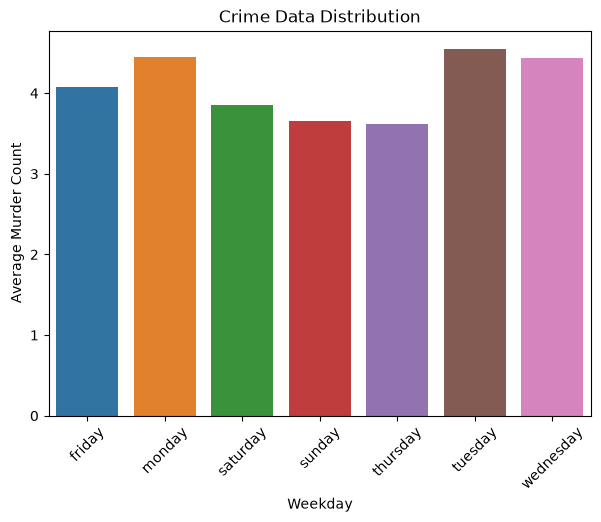

In [55]:
plt.figure(figsize=(7,5))
sns.barplot(x = avg_murder_per_weekday.index,y = avg_murder_per_weekday.values, hue=["skyblue", "orange", "green", "maroon", "brown", "blue", "purple"], legend=False)
plt.title("Crime Data Distribution")
plt.xlabel("Weekday")
plt.ylabel("Average Murder Count")
plt.xticks(rotation=45)
plt.show()

In [56]:
df["crime"].unique()

<StringArray>
['murder', 'rape', 'assault', 'bodyfound', 'kidnap', 'robbery']
Length: 6, dtype: str

In [ ]:
map_df = df.groupby(["incident_place", "latitude", "longitude", "crime"]).size().reset_index(name='total_crimes')
bd_map = folium.Map(location=[23.6850, 90.3563], zoom_start=7, tiles="OpenStreetMap")
#crime wise color selestion
clr_map = {
    "murder":"red",
    "bodyfound":"darkred",
    "rape":"purple",
    "assault":"orange",
    "kidnap":"blue",
    "robbery":"green"
}
for idx, row in map_df.iterrows():
    #if not crime in group list--> default clr:gray
    m_clr = clr_map.get(row["crime"], "gray")

    folium.CircleMarker(
        location = [row["latitude"], row["longitude"]],
        radius = min(row["total_crimes"] * 0.5,20),
        popup = f"<b>Place:</b> {row['incident_place']}<br><b>Crime:</b> {row['crime']}<br><b>Total:</b> {row["total_crimes"]}",
        color = m_clr,
        fill=True,
        fill_color=True,
        fill_opacity=0.6
        ).add_to(bd_map)


bd_map

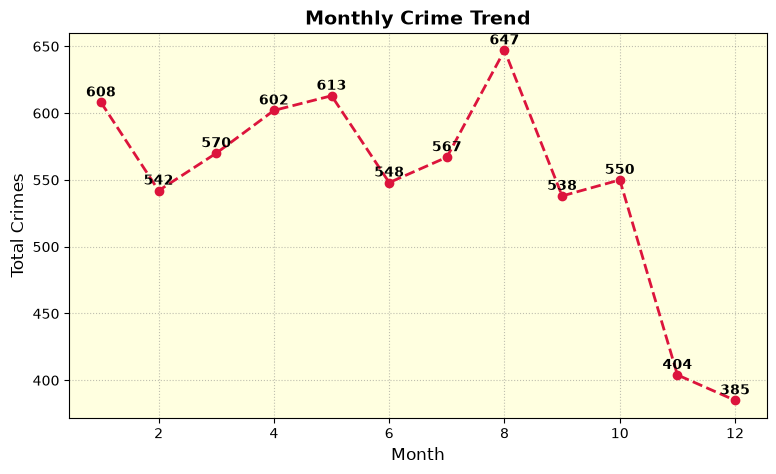

In [ ]:
#monthly crime
monthly_counts = df.groupby('incident_month').size()

plt.figure(figsize=(9, 5))


ax = plt.gca()
ax.set_facecolor('lightyellow') 


plt.plot(monthly_counts.index, monthly_counts.values, marker='o', linestyle="--", color="crimson", linewidth=2)

for x, y in zip(monthly_counts.index, monthly_counts.values):
    plt.text(x, y + 2, str(y), ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')
    # y + 2, to move 2 tiles upward

plt.title("Monthly Crime Trend", fontsize=14, fontweight='bold')
plt.xlabel("Month", fontsize=12)
plt.ylabel("Total Crimes", fontsize=12)

plt.grid(True, linestyle=':', alpha=0.5, color='gray')
plt.show()


### Monthly Crime Analysis
- It seems most of the time crime goes peak in August.

In [60]:
df.season.unique()

<StringArray>
['rainy', 'winter', 'hot']
Length: 3, dtype: str

In [61]:
df_enc = pd.get_dummies(df, columns=["season","crime"], drop_first=True)

## Spatial Analysis

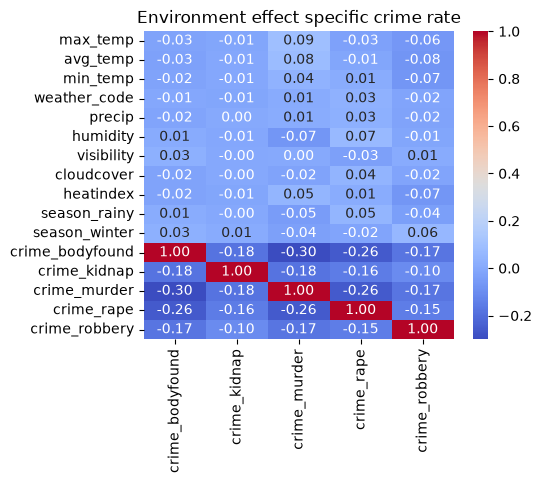

In [62]:
environment_features = ["max_temp", "avg_temp", "min_temp", "weather_code", "precip", "humidity", "visibility", "cloudcover", "heatindex"]
dummy_cols = [col for col in df_enc.columns if col.startswith("season_")]
crime_col = [col for col in df_enc.columns if col.startswith("crime_")]
env_feature = environment_features+dummy_cols+crime_col

env_corr = df_enc[env_feature].corr()

plt.figure(figsize=(5,4))
sns.heatmap(env_corr.loc[env_feature, crime_col], annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Environment effect specific crime rate")
plt.show()


## Heatmap Analysis
- Crime type dummy variables exhibit expected negative correlations because each incident belongs to exactly one crime category. Therefore, these correlations are a consequence of one-hot encoding rather than evidence of an inverse relationship between different crime types.

In [75]:
#what is park & police station effect crime rate
crime_summery = df.groupby(["park", "police_station"]).size().reset_index(name="total_crimes")
print(crime_summery)


    park  police_station  total_crimes
0      0               0            28
1      0               1           795
2      0               2           784
3      0               3           475
4      0               4           171
5      0               5            82
6      0               6            45
7      0               7           107
8      0               8            26
9      0              10            14
10     0              12            10
11     1               1           341
12     1               2           336
13     1               3           231
14     1               4            45
15     1               5           132
16     1               6            62
17     1               8            12
18     1              10             8
19     1              74             2
20     2               1            86
21     2               2           358
22     2               3            34
23     2               4            18
24     2               5 

In [82]:
#place wise crime
place_wise_crime = df.groupby("incident_place")["crime"].count().reset_index(name="total_crimes").sort_values(by="total_crimes", ascending=False)
print(f"Place wise total crimes:\n{place_wise_crime}")

Place wise total crimes:
                     incident_place  total_crimes
131                 chattogram city           224
566                           savar           194
624                    sylhet sadar            96
519                   rajshahi city            85
285                   jessore sadar            81
..                              ...           ...
601  sir salimullah medical college             1
651                   uttar kattali             1
611                 south sunamganj             1
26                           atpara             1
654                          vatara             1

[660 rows x 2 columns]


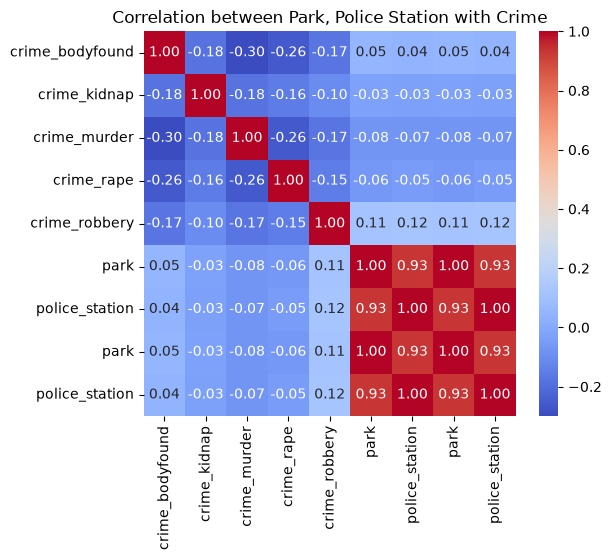

In [86]:
#correlation between park, police station and crime
crime_col = crime_col+["park","police_station"]
crime_corr = df_enc[crime_col].corr()

plt.figure(figsize=(6,5))
sns.heatmap(crime_corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation between Park, Police Station with Crime")
plt.show()

## Heatmap Analysis

- There is no significant correlation observed. Lets try aggregating this three feature in a separate data frame and then check again.

In [93]:
same_place = df[(df["incident_place"] == "adabor") | (df["incident_place"] == "adabar")]
print(same_place)

     incident_month  incident_week incident_weekday  weekend part_of_the_day  \
0                 7             29        wednesday        0         morning   
1                 1              2        wednesday        0           night   
2                 1              4          tuesday        0           night   
559              12             52         thursday        0         morning   
560               3             10         thursday        0           night   
561               1              2           friday        1         morning   
887               7             26           sunday        0         morning   
902               7             30         thursday        0         morning   

      latitude  longitude incident_place incident_district incident_division  \
0    23.774569  90.355292         adabar             dhaka             dhaka   
1    23.774569  90.355292         adabar             dhaka             dhaka   
2    23.769808  90.351595         adabo

In [95]:
df["incident_place"] = df["incident_place"].replace("adabar","adabor")

In [116]:
place_summery = df.groupby("incident_place").agg(
    total_crimes = ('crime', 'count'),
    total_park = ('park', 'nunique'),
    total_field = ('playground', 'nunique'),
    total_police_station = ('police_station', 'nunique')
).reset_index()

In [117]:
place_summery.sort_values(by="total_crimes", ascending=False)

,incident_place,total_crimes,total_park,total_field,total_police_station
130,chattogram city,224,1,1,1
565,savar,194,1,1,1
623,sylhet sadar,96,1,1,1
518,rajshahi city,85,1,1,1
284,jessore sadar,81,1,1,1
...,...,...,...,...,...
600,sir salimullah medical college,1,1,1,1
178,dholaikhal,1,1,1,1
653,vatara,1,1,1,1
650,uttar kattali,1,1,1,1


## Place Summery
- These locations appear to have fewer parks/playgrounds/police stations alongside higher crime counts. Further statistical analysis is required before inferring any relationship

In [112]:
#In which place in which time what type of crime is more often occurs
crime_analysis = df.groupby(["incident_place", "part_of_the_day", "crime"]).size().reset_index(name="crime_count")

most_frequent_daytime = crime_analysis.loc[crime_analysis.groupby(["incident_place","part_of_the_day"])["crime_count"].idxmax()]
most_frequent_daytime.head()

,incident_place,part_of_the_day,crime,crime_count
0,abhaynagar,afternoon,assault,1
1,abhaynagar,morning,murder,2
5,abhaynagar,night,rape,5
6,abhaynagar,noon,bodyfound,1
8,adabor,morning,bodyfound,2


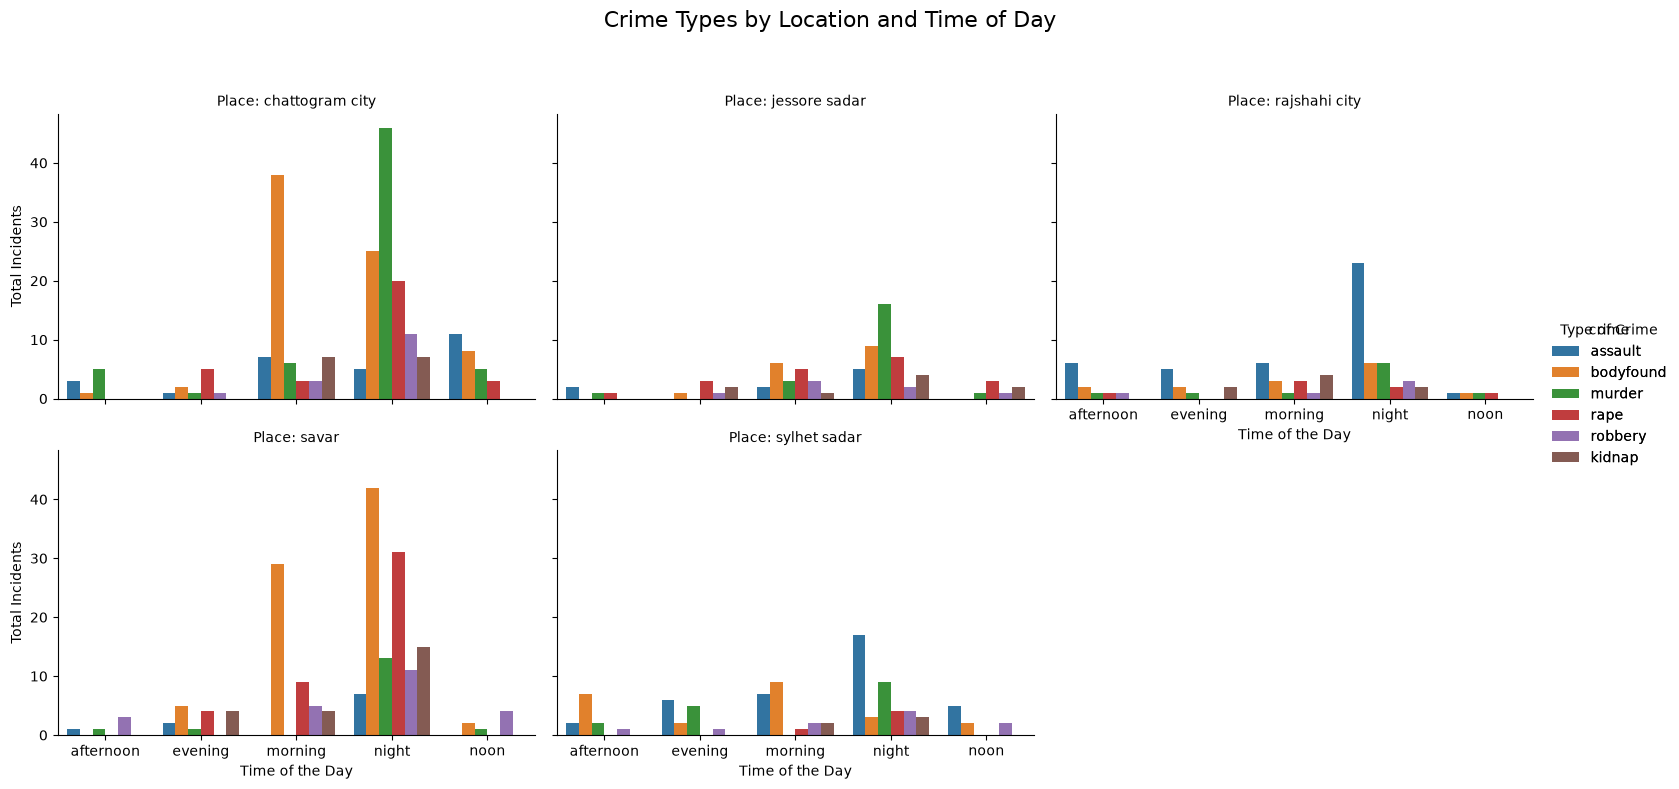

In [114]:
# যদি আপনার ডেটাসেটে জায়গার সংখ্যা অনেক বেশি হয়, তবে প্রথম ৫টি বা ১০টি পপুলার জায়গা ফিল্টার করে প্লট করা ভালো
top_places = df["incident_place"].value_counts().nlargest(5).index
df_filtered = crime_analysis[crime_analysis["incident_place"].isin(top_places)]

# ক্যাটপ্লট তৈরি
graph = sns.catplot(
    data=df_filtered,
    x="part_of_the_day",
    y="crime_count",
    hue="crime",
    col="incident_place",  # প্রতিটি জায়গার জন্য আলাদা কলাম বা সাব-প্লট হবে
    kind="bar",
    col_wrap=3,            # প্রতি লাইনে সর্বোচ্চ ৩টি করে গ্রাফ দেখাবে
    palette="tab10",
    height=4,
    aspect=1.2
)

# গ্রাফের সৌন্দর্য বর্ধন
graph.set_axis_labels("Time of the Day", "Total Incidents")
graph.set_titles("Place: {col_name}")
graph.add_legend(title="Type of Crime")
plt.subplots_adjust(top=0.85)
graph.fig.suptitle("Crime Types by Location and Time of Day", fontsize=16)

plt.show()
